### Zomato Data Analysis Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Create the data Frame

In [2]:
dataframe = pd.read_csv("zomato.csv")


In [4]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


### Data Cleaning

In [6]:
# conveting the rating to 4.1/5 to 4.1
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)
dataframe['rate'] = dataframe['rate'].apply(handleRate)
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [10]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


### Type of Resturant 

In [11]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'Type of Restarant')

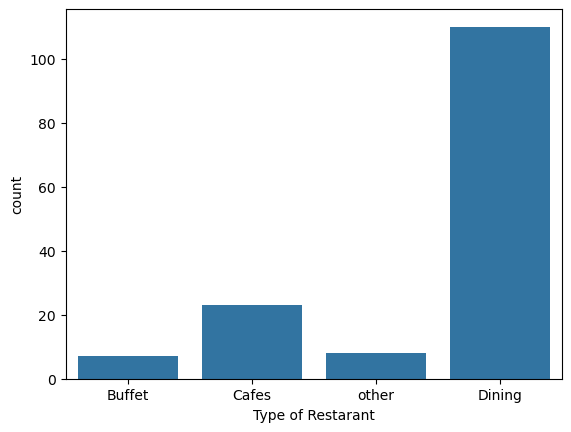

In [12]:
sns.countplot(x = dataframe['listed_in(type)'])
plt.xlabel('Type of Restarant')

In [13]:
# conclusion - majority of resturent falls in dining category 

Text(0, 0.5, 'votes')

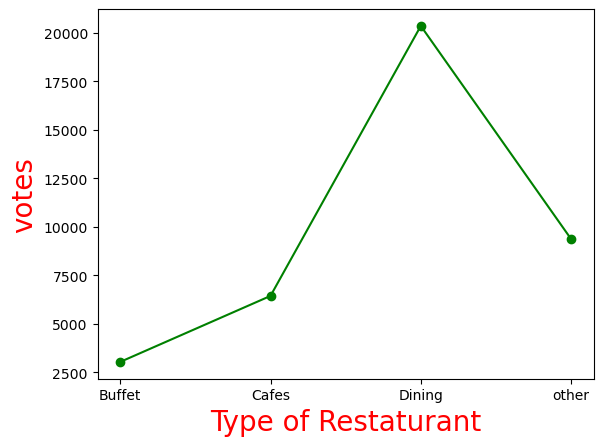

In [14]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c="green" , marker = "o")
plt.xlabel("Type of Restaturant" , c= "red" , size = 20)
plt.ylabel("votes" , c ="red", size = 20)

### conclusion - dining restarants has received maximum votes

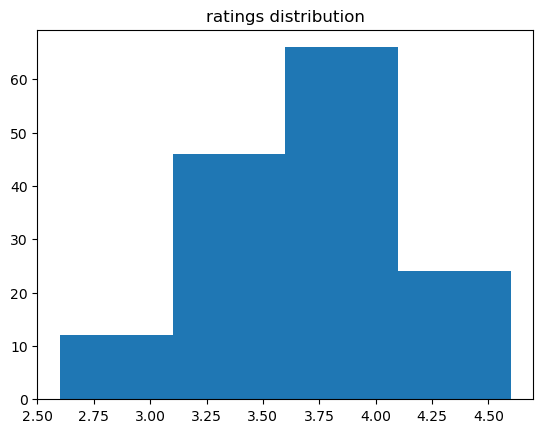

In [18]:
plt.hist(dataframe['rate'],bins = 4)
plt.title("ratings distribution")
plt.show()

### conclusion - Majority resturants received ratigns from 3.5 to 4

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

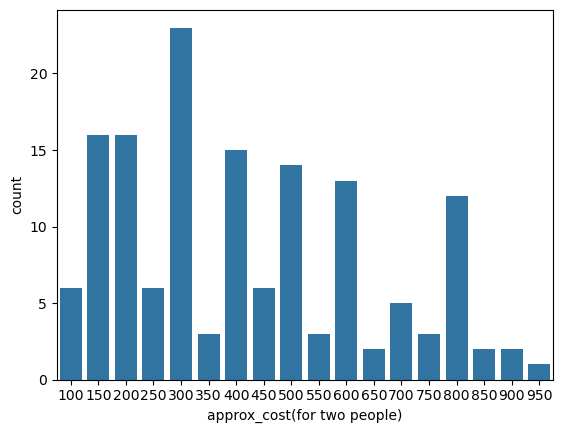

In [20]:
couple_data = dataframe['approx_cost(for two people)']
sns.countplot( x= couple_data)

### conclusion - the majority of couples perfer resturants with aproximately cost of 300 rupees

In [21]:
# Which mode of restuarant recieved maximam rating


<Axes: xlabel='online_order', ylabel='rate'>

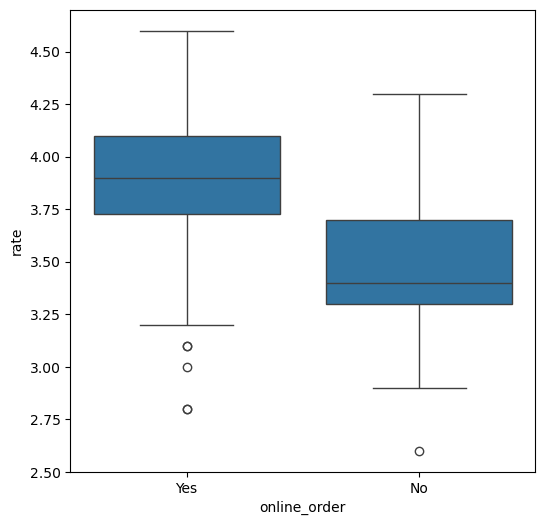

In [22]:
plt.figure(figsize=(6,6))
sns.boxplot(x= 'online_order',y = 'rate' , data = dataframe)

### conclusion - Online order received lower rating in the order

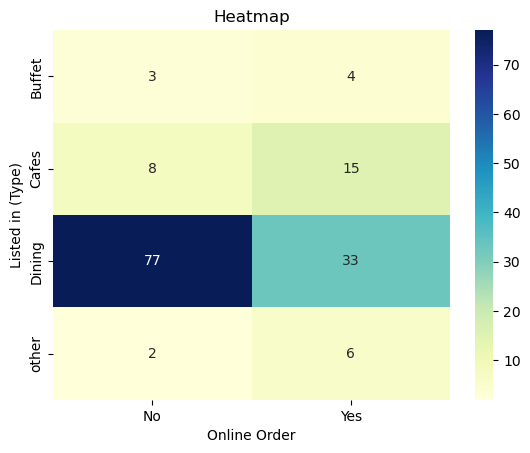

In [26]:
pivot_table = dataframe.pivot_table(index ='listed_in(type)',columns = 'online_order', aggfunc = 'size' , fill_value = 0)
sns.heatmap(pivot_table, annot= True , cmap= "YlGnBu" , fmt = "d")
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed in (Type)")
plt.show()

### Conclusion : Dining restaurants primarly accept offiline orders whereas cafes primarly recive online orders . This suggests that cilents preferred order in person at resaurants , but online ordering at cafes